# Product Sales Recommendation System – Exploratory Data Analysis (EDA)

## Business Context
A company sells products through multiple channels. The goal is to analyze sales
transactions and customer purchase behavior to support a product recommendation system.

## Objectives
- Identify frequently co-purchased products (market basket)
- Analyze seasonal and regional demand patterns
- Detect high-return or low-satisfaction products (if available)
- Understand customer purchasing behavior (RFM segmentation)

## Tools
Python, Pandas, NumPy, Matplotlib, mlxtend



In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
os.listdir()

['.ipynb_checkpoints', 'data.csv', 'product_recommendation_eda.ipynb']

In [11]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [12]:
df.shape

#rows and columns

(541909, 8)

In [13]:
df.info()

#for data understanding(Which columns have missing values, data types)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [14]:
df.isna().sum()

#check missing values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [15]:
# Remove duplicates
df = df.drop_duplicates()

# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Remove missing critical values
df = df.dropna(subset=["InvoiceNo", "Description", "Quantity", "UnitPrice"])

# Remove cancellations and invalid rows
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

# Create sales metric
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.shape


(524878, 9)

##### Business Overview Matrix (How big the business is?)

Overall scale of sales

Customer base size

Product diversity

In [16]:
print("Total Revenue:", round(df["TotalPrice"].sum(), 2))
print("Total Orders:", df["InvoiceNo"].nunique())
print("Total Products:", df["Description"].nunique())
print("Total Customers:", df["CustomerID"].nunique())
print("Countries Served:", df["Country"].nunique())

Total Revenue: 10642110.8
Total Orders: 19960
Total Products: 4026
Total Customers: 4338
Countries Served: 38


###### Identify best-selling products → useful for recommendations & bundling.

In [20]:
top_products = (
    df.groupby("Description")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products


Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: TotalPrice, dtype: float64

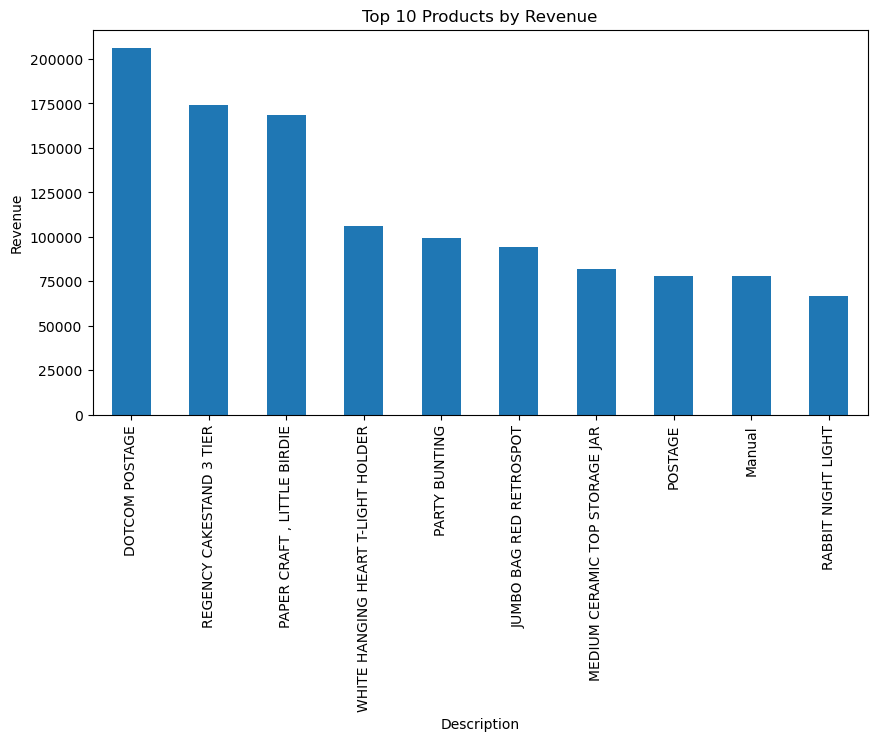

In [21]:
top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()


#plot

###### Time based analysis (seasonality)

When do customer buy more?

In [22]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("YearMonth")["TotalPrice"].sum()

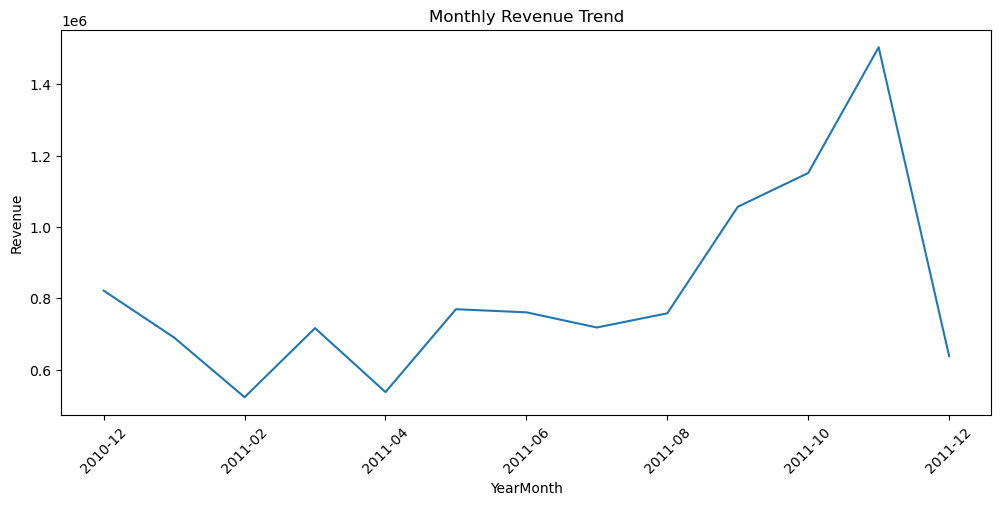

In [23]:
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## Country/Region Analysis

In [24]:
top_countries = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_countries


Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

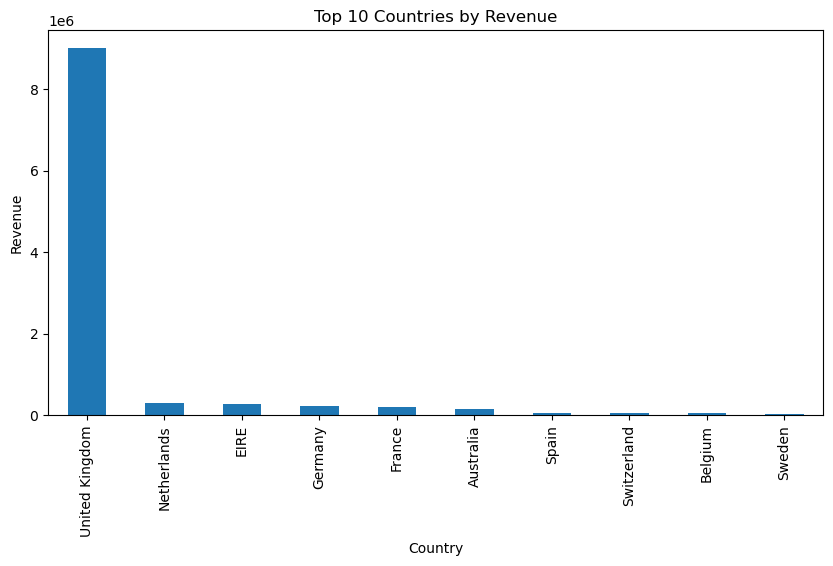

In [25]:
top_countries.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()


## Exploratory Data Analysis Insights

- A small number of products contribute a large portion of total revenue.
- Sales show clear seasonal patterns across months.
- The United Kingdom is the dominant market, followed by other European countries.
- These insights help tailor product recommendations by time and region.


# Market Basket Analysis

Which products are frequently bought together?

In [26]:
df.shape

(524878, 10)

In [27]:
from mlxtend.frequent_patterns import apriori, association_rules

##### The Basket Matrix
- Rows = invoices
- Columns = products
- Values = whether the product was bought (True / False

In [28]:
basket = (
    df.groupby(["InvoiceNo", "Description"])["Quantity"]
      .sum()
      .unstack()
      .fillna(0)
)

In [29]:
basket = basket > 0

In [30]:
basket.head()


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)


In [32]:
frequent_items.head()


,support,itemsets
0,0.013477,( SET 2 TEA TOWELS I LOVE LONDON )
1,0.015932,(10 COLOUR SPACEBOY PEN)
2,0.012575,(12 MESSAGE CARDS WITH ENVELOPES)
3,0.017786,(12 PENCIL SMALL TUBE WOODLAND)
4,0.018136,(12 PENCILS SMALL TUBE RED RETROSPOT)


In [34]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.2
)

In [30]:
rules = rules[
    rules["antecedents"].apply(lambda x: len(x) == 1) &
    rules["consequents"].apply(lambda x: len(x) == 1)
]

In [31]:
recommendations = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].sort_values("lift", ascending=False)

recommendations.head(10)


,antecedents,consequents,support,confidence,lift
441,(HERB MARKER THYME),(HERB MARKER ROSEMARY),0.011072,0.932489,77.552039
440,(HERB MARKER ROSEMARY),(HERB MARKER THYME),0.011072,0.920833,77.552039
439,(HERB MARKER THYME),(HERB MARKER PARSLEY),0.010671,0.898734,75.372833
438,(HERB MARKER PARSLEY),(HERB MARKER THYME),0.010671,0.894958,75.372833
437,(HERB MARKER ROSEMARY),(HERB MARKER PARSLEY),0.010772,0.895833,75.129552
436,(HERB MARKER PARSLEY),(HERB MARKER ROSEMARY),0.010772,0.903361,75.129552
431,(HERB MARKER MINT),(HERB MARKER PARSLEY),0.010621,0.883333,74.081232
430,(HERB MARKER PARSLEY),(HERB MARKER MINT),0.010621,0.890756,74.081232
426,(HERB MARKER ROSEMARY),(HERB MARKER BASIL),0.010721,0.891667,73.544077
427,(HERB MARKER BASIL),(HERB MARKER ROSEMARY),0.010721,0.884298,73.544077


# Decision Tree
Under what conditions does sales revenue become high or low?

In [33]:
# Decision Trees work best for classification, so we’ll convert revenue into categories.
# Create revenue categories using quantiles
df["SalesLevel"] = pd.qcut(
    df["TotalPrice"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df["SalesLevel"].value_counts()


SalesLevel
Low       179292
High      173646
Medium    171940
Name: count, dtype: int64

In [35]:
# Extract Month from InvoiceDate
df["Month"] = df["InvoiceDate"].dt.month

In [36]:
# Select features  
X = df[["Quantity","UnitPrice", "Month"]]
y = df["SalesLevel"]

In [37]:
# To evaluate model performance on unseen data.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [38]:
# Build the Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
from sklearn.metrics import accuracy_score

y_pred = dt_model.predict(X_test)
accuracy_score(y_test, y_pred)
# Evaluate the model

0.9266880048773053

In [40]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
1,UnitPrice,0.614379
0,Quantity,0.385621
2,Month,0.000000


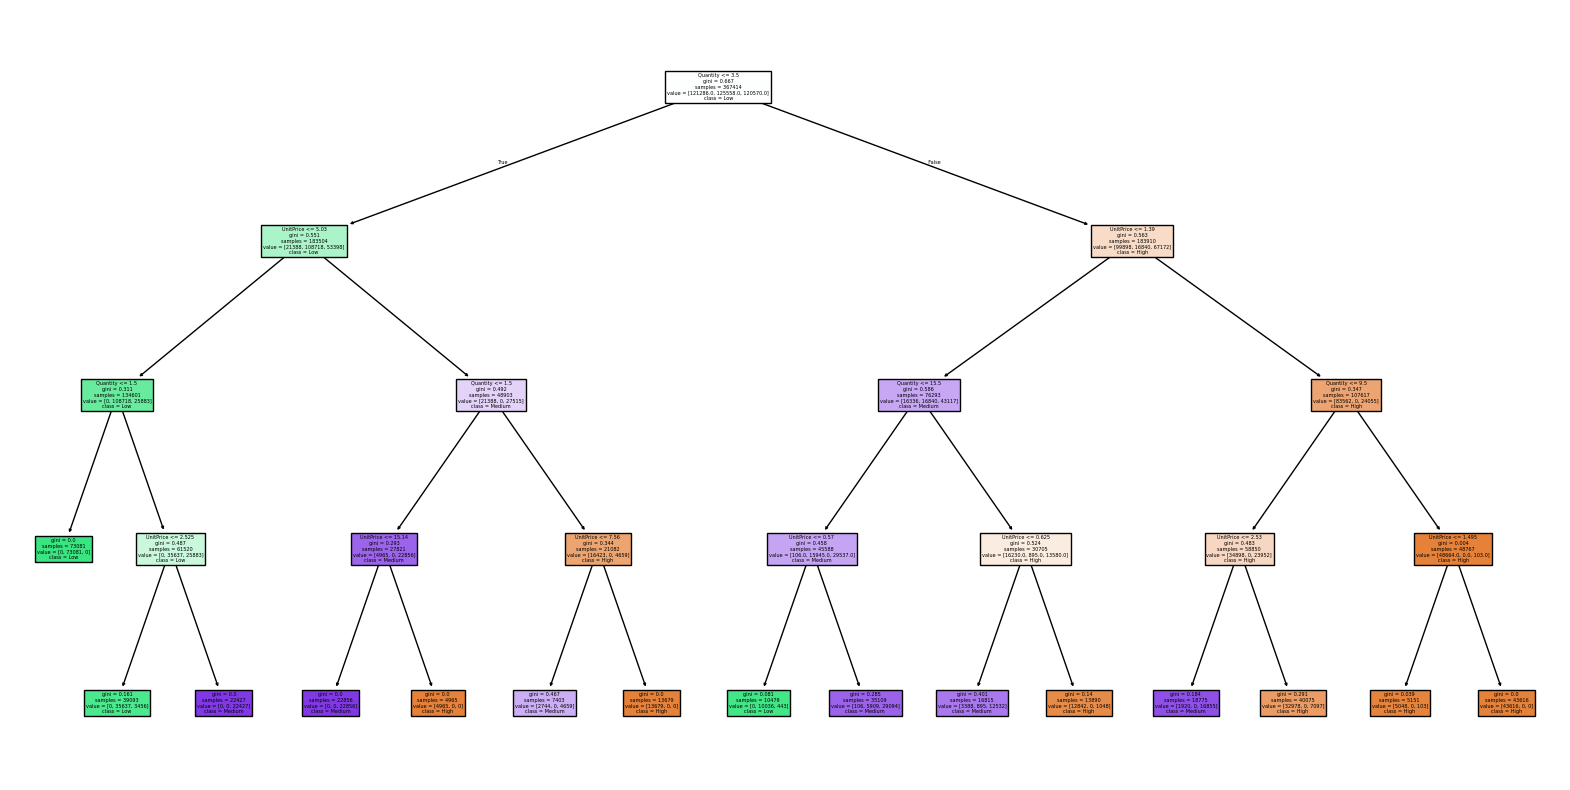

In [41]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True
)
plt.show()


I used a Decision Tree to understand under what conditions sales become high or low.
Unlike regression, the tree captures non-linear patterns and produces clear if–then rules, which are easier for business interpretation.

# What are the predictions of the test data?


In [42]:
# Predict on test data
y_pred = dt_model.predict(X_test)

# Show first 10 predictions vs actual
pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})


,Actual,Predicted
0,Low,Low
1,High,High
2,Medium,Medium
3,High,High
4,Low,Low
5,High,High
6,High,High
7,High,High
8,High,High
9,High,High


The model predicts whether each transaction belongs to Low, Medium, or High sales based on quantity, unit price, and month.

# Random Forest (Improved Model)
Why Random Forest?

Decision Tree = one tree → can overfit

Random Forest = many trees + averaging

More stable, better generalization

Random Forest improves performance by averaging multiple decision trees, reducing variance and improving prediction stability.

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_accuracy


0.9319971549052481

# Hyperparameter Tuning (Grid Search)
Why tuning?

Default parameters are not optimal.
Grid Search finds the best combination automatically using cross-validation.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 2, 5]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_
best_dt


,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
# Evaluate tuned model
best_pred = best_dt.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)
best_accuracy

0.9896230249453843

Hyperparameter tuning improved model generalization by controlling tree complexity using cross-validation.

# Confusion Matrix

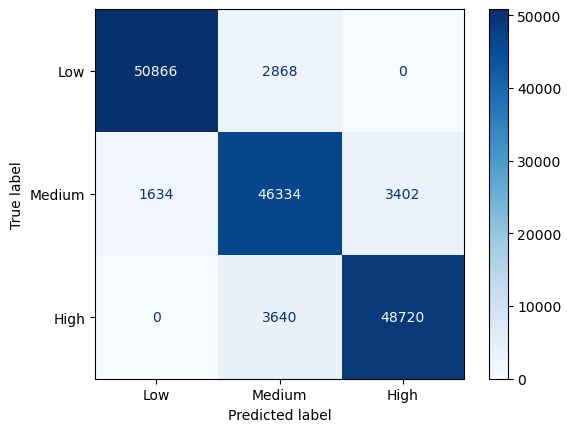

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low", "Medium", "High"]
)

disp.plot(cmap="Blues")
plt.show()


The confusion matrix shows how many observations were correctly classified and where misclassifications occurred, particularly between medium and high sales levels.

# Precision, Recall, F1-Score

Why accuracy is not enough

Accuracy hides which class is failing.

Precision & Recall explain quality of predictions.

### How to interpret 
1. Precision

“When the model predicts High, how often is it correct?”

2. Recall

“Out of all actual High sales, how many did the model detect?”

3. F1-Score

Balance between precision and recall

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        High       0.93      0.93      0.93     52360
         Low       0.97      0.95      0.96     53734
      Medium       0.88      0.90      0.89     51370

    accuracy                           0.93    157464
   macro avg       0.93      0.93      0.93    157464
weighted avg       0.93      0.93      0.93    157464



The model achieves high precision and recall across all sales categories, with most misclassifications occurring in the medium sales range due to overlapping transaction behavior